In [1]:
#Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import os


In [2]:
#Dataset Paths
train_path = "dataset/train"
test_path = "dataset/test"


In [3]:
#Image PreProcessing
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=False,
    class_mode='categorical'
)

Found 381 images belonging to 4 classes.
Found 260 images belonging to 4 classes.


In [4]:
# Inspect class distribution to see if the dataset is balanced

def get_class_counts(directory):
    counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir):
            continue
        counts[class_name] = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
    return counts

print("Train class distribution:")
print(get_class_counts(train_path))

print("Test class distribution:")
print(get_class_counts(test_path))


Train class distribution:
{'Grassy_shoot': 100, 'Healthy_Leaves': 100, 'Red_Rot': 81, 'Yellow_Leaf': 100}
Test class distribution:
{'Grassy_shoot': 80, 'Healthy_Leaves': 80, 'Red_Rot': 20, 'Yellow_Leaf': 80}


In [5]:
#CNN Model
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))   # 5 classes                                                                          

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(model.input_shape)


e:\SUGARCANE_DISEASE_PEEDICTION\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

(None, 224, 224, 3)


In [6]:

# Train Model (use class weights for imbalance)
class_labels = train_data.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels),
    y=class_labels,
)
class_weight = dict(enumerate(class_weights))
print("Class weights:", class_weight)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    class_weight=class_weight,
)

Class weights: {0: np.float64(0.9525), 1: np.float64(0.9525), 2: np.float64(1.1759259259259258), 3: np.float64(0.9525)}
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.3202 - loss: 2.1447 - val_accuracy: 0.3808 - val_loss: 1.1876
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.5512 - loss: 0.9950 - val_accuracy: 0.4769 - val_loss: 0.9837
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.6378 - loss: 0.7859 - val_accuracy: 0.6423 - val_loss: 0.9663
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7612 - loss: 0.6234 - val_accuracy: 0.8538 - val_loss: 0.5242
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8084 - loss: 0.4930 - val_accuracy: 0.8769 - val_loss: 0.4552
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8530 - loss: 0.4248 - val_accuracy: 0.9192 - val_loss: 0.2716
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9108 - loss: 0.2800 - val_accuracy: 0.9038 - val_loss: 0.238

In [7]:
#Model Evaluation
loss, accuracy = model.evaluate(test_data)

print("Accuracy:", accuracy)


9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 534ms/step - accuracy: 0.9538 - loss: 0.2459
Accuracy: 0.9538461565971375


9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 516ms/step


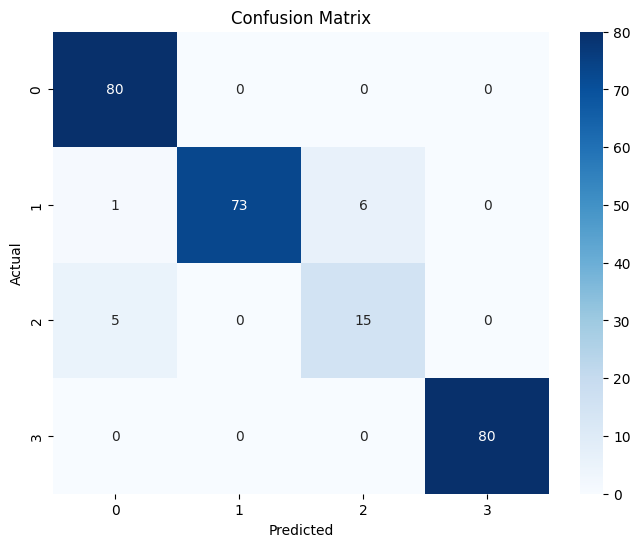

In [8]:

#Confusion Matrix
Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:

#F1 Score + Classification Report
print(classification_report(y_true, y_pred))

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        80
           1       1.00      0.91      0.95        80
           2       0.71      0.75      0.73        20
           3       1.00      1.00      1.00        80

    accuracy                           0.95       260
   macro avg       0.91      0.92      0.91       260
weighted avg       0.96      0.95      0.95       260

F1 Score: 0.954163266759419


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Prediction: Red_Rot
Prediction vector (probabilities): [5.9601581e-03 1.3665737e-05 9.9402595e-01 1.5451911e-07]


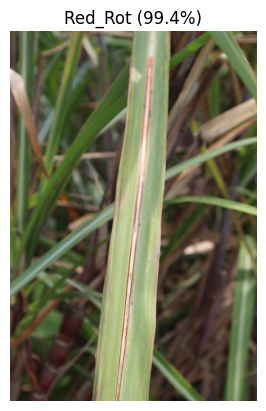

In [10]:

# Predict Disease From New Image
# Build a label mapping that matches the generator's numeric labels.
idx_to_class = {v: k for k, v in train_data.class_indices.items()}

# Optional: persist mapping for external usage (e.g., Streamlit app)
import json
with open("class_indices.json", "w") as f:
    json.dump(train_data.class_indices, f, indent=2)


def predict_image(img_path, show_plot=True):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    prediction = model.predict(img_input)
    predicted_index = int(np.argmax(prediction, axis=1)[0])
    predicted_class = idx_to_class[predicted_index]

    print("Prediction:", predicted_class)
    print("Prediction vector (probabilities):", prediction[0])

    if show_plot:
        plt.imshow(img_rgb)
        plt.title(f"{predicted_class} ({prediction[0][predicted_index]*100:.1f}%)")
        plt.axis("off")
        plt.show()


predict_image(r"E:\SUGARCANE_DISEASE_PEEDICTION\dataset\test\Red_Rot\S_RR (84).JPG")